In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
df=pd.read_csv('HR_comma_sep.csv')

In [2]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


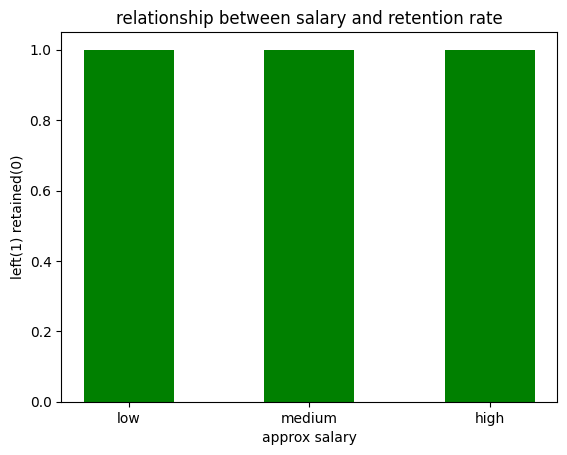

In [3]:
plt.bar(df['salary'], df.left, color='green',width=0.5)
plt.xlabel('approx salary')
plt.ylabel('left(1) retained(0)')
plt.title('relationship between salary and retention rate')
plt.show()

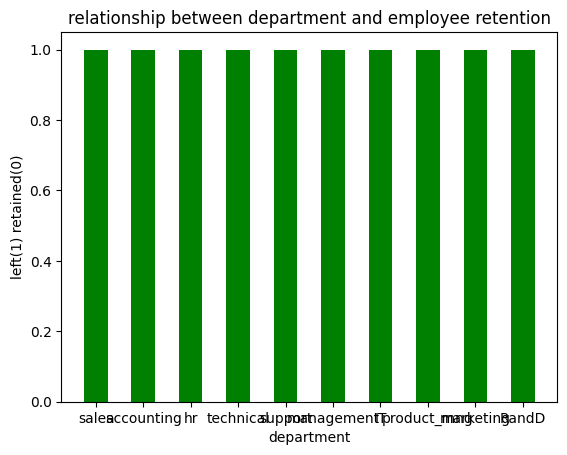

In [4]:
plt.bar(df['Department'], df.left, color='green',width=0.5)
plt.xlabel('department')
plt.ylabel('left(1) retained(0)')
plt.title('relationship between department and employee retention')
plt.show()

In [ ]:
left= df[df.left==1]
left.shape#separates dataset of retained and left employees with all information

(3571, 10)

In [6]:
retained=df[df.left==0]
retained.shape

(11428, 10)

In [7]:
#average numbers for all columns of left employees
f1=left[['satisfaction_level','last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company','Work_accident','promotion_last_5years']].mean()
f1['average_montly_hours']=f1['average_montly_hours']/100
f1

satisfaction_level       0.440098
last_evaluation          0.718113
number_project           3.855503
average_montly_hours     2.074192
time_spend_company       3.876505
Work_accident            0.047326
promotion_last_5years    0.005321
dtype: float64

In [8]:
#average numbers for all columns of retained employees
f2=retained[['satisfaction_level','last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company','Work_accident','promotion_last_5years']].mean()
f2['average_montly_hours']=f2['average_montly_hours']/100
f2

satisfaction_level       0.666810
last_evaluation          0.715473
number_project           3.786664
average_montly_hours     1.990602
time_spend_company       3.380032
Work_accident            0.175009
promotion_last_5years    0.026251
dtype: float64

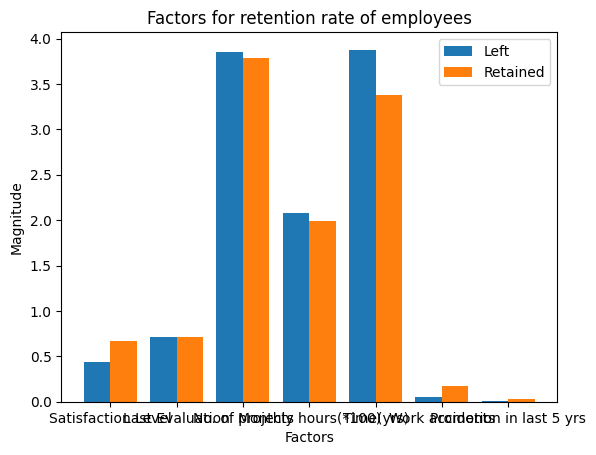

In [9]:
#difference amongst employees on the basis of certain factors
import numpy as np
X=['Satisfaction Level', 'Last Evaluation', 'No. of projects', 'Monthly hours(*100)', 'Time(yrs)','Work accidents', 'Promotion in last 5 yrs']
Xaxis=np.arange(len(X))
plt.bar(Xaxis-0.2, f1, 0.4, label='Left')
plt.bar(Xaxis+0.2, f2, 0.4, label='Retained')
plt.xticks(Xaxis, X)
plt.xlabel('Factors')
plt.ylabel("Magnitude")
plt.title('Factors for retention rate of employees')
plt.legend()
plt.show()

<Axes: xlabel='Department'>

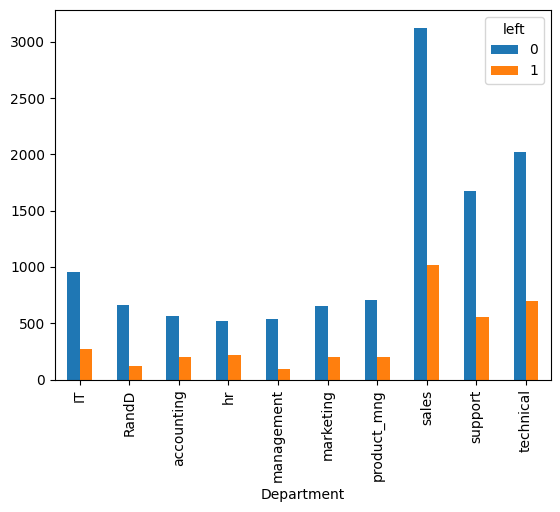

In [10]:
#department wise retention rate
pd.crosstab(df.Department, df.left).plot(kind='bar')

<Axes: xlabel='salary'>

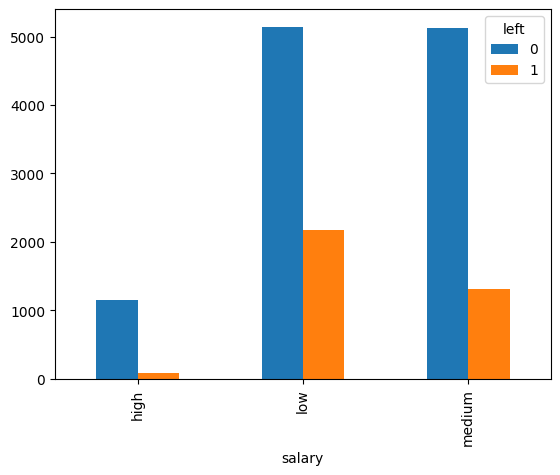

In [11]:
#salary wise retention rate
pd.crosstab(df.salary,df.left).plot(kind='bar')

We can conclude that these independent variables affect the retention rate of an employee are :

Satisfaction Level, Average Monthly Hours, Promotion in last 5 years, Salary

In [12]:
sub=df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
sub.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [13]:
dummies=pd.get_dummies(sub.salary, prefix='S')

In [14]:
dfd=pd.concat([sub, dummies], axis='columns')
dfd.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,S_high,S_low,S_medium
0,0.38,157,0,low,False,True,False
1,0.80,262,0,medium,False,False,True
2,0.11,272,0,medium,False,False,True
3,0.72,223,0,low,False,True,False
4,0.37,159,0,low,False,True,False


In [15]:
dfd.drop('salary', axis='columns', inplace=True)
dfd.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,S_high,S_low,S_medium
0,0.38,157,0,False,True,False
1,0.80,262,0,False,False,True
2,0.11,272,0,False,False,True
3,0.72,223,0,False,True,False
4,0.37,159,0,False,True,False


In [16]:
Y=df.left
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split
X=dfd
xt,xtest,yt,ytest=train_test_split(X,Y,train_size=0.8, random_state=33)

In [18]:
from sklearn.linear_model import LogisticRegression
reg=LogisticRegression()

In [19]:
reg.fit(xt,yt)

LogisticRegression()

In [20]:
reg.predict(xtest)

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [21]:
reg.score(xtest,ytest)

0.7736666666666666